### seaborn.heatmap

`heatmap` plots rectangular data as a **color-encoded** matrix.<br/>

The heatmap will be drawn in the currently active Axes (or the Axes specified in the `ax` argument).<br/>
Also, a colormap will be drawn to the right of the heatmap (unless `cbar` is False).<br/>

<pre style="font-family:'Courier New';font-size:1.0em;">
<span style="color:orange;font-weight:600;">sns</span>.<span style="color:darkblue;font-weight:600;">heatmap</span>(
    data,       # DataFrame where index/column information is used to label the rows and columns.
    vmin, vmax  # Values to anchor the colormap (inferred from data if not provided).
    cmap,       # The mapping from data values to color space.
    center,     # The value on which to center the colormap. It will change the 
                # default cmap (if not specified).
    robust,     # If True and vmin/vmax not specified, colormap range is computed with robust  
                #  quantiles and not the extreme data values.
    annot       # Writes the data value in each cell.
    fmt,        # String formatting code for annotations.
    annot_kws,  # dict with keyword arguments for ax.text() when annot is True.
    linewidths, # Width of the lines of each cell.
    linecolor,  # Color of the lines of each cell.
    cbar,       # Whether to draw a colorbar.
    cbar_kws,   # Keyword arguments for fig.colorbar().
    cbar_ax,    # Separate Axes to draw the colorbar; otherwise take space from main Axes.
    square,     # When True, it sets the Axes aspect to "equal".
    xticklabels,# If True, plot the column names of the dataframe. 
    yticklabels,#
    mask,       # Does not show data in cells where mask is True
    ax,         # Axes on which to draw the plot (or the currently-active Axes).
    kwargs,     # keyword arguments passed to pcolormesh()
)
</pre>

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the general style; pre-configured styles: white, whitegrid, dark, darkgrid
sns.set_style("darkgrid")

### Examples

##### 1. Pass a `DataFrame` to plot with indices and row/column labels:

In [10]:
glue = sns.load_dataset("glue")

In [11]:
glue

,Model,Year,Encoder,Task,Score
0,ERNIE,2019,Transformer,CoLA,75.5
1,T5,2019,Transformer,CoLA,71.6
2,RoBERTa,2019,Transformer,CoLA,67.8
3,BERT,2018,Transformer,CoLA,60.5
4,BiLSTM+ELMo,2018,LSTM,CoLA,32.1
...,...,...,...,...,...
59,BERT,2018,Transformer,RTE,70.1
60,BiLSTM+ELMo,2018,LSTM,RTE,57.4
61,BiLSTM+CoVe,2017,LSTM,RTE,52.7
62,BiLSTM+Attn,2017,LSTM,RTE,58.4


In [12]:
# pivot() reshapes the DataFrame based on column values:
# Use the values of the "Model" column as the index.
# Use the values of the "Task" column  as the columns.
glue = glue.pivot(index="Model", columns="Task", values="Score")
glue

Task,CoLA,MNLI,MRPC,QNLI,QQP,RTE,SST-2,STS-B
Model,,,,,,,,
BERT,60.5,86.7,89.3,92.7,72.1,70.1,94.9,87.6
BiLSTM,11.6,65.6,81.8,74.6,62.5,57.4,82.8,70.3
BiLSTM+Attn,18.6,67.6,83.9,74.3,60.1,58.4,83.0,72.8
BiLSTM+CoVe,18.5,65.4,78.7,70.8,60.6,52.7,81.9,64.4
BiLSTM+ELMo,32.1,67.2,84.7,75.5,61.1,57.4,89.3,70.3
ERNIE,75.5,92.3,93.9,97.3,75.2,92.6,97.8,93.0
RoBERTa,67.8,90.8,92.3,95.4,74.3,88.2,96.7,92.2
T5,71.6,92.2,92.8,96.9,75.1,92.8,97.5,93.1


<Axes: xlabel='Task', ylabel='Model'>

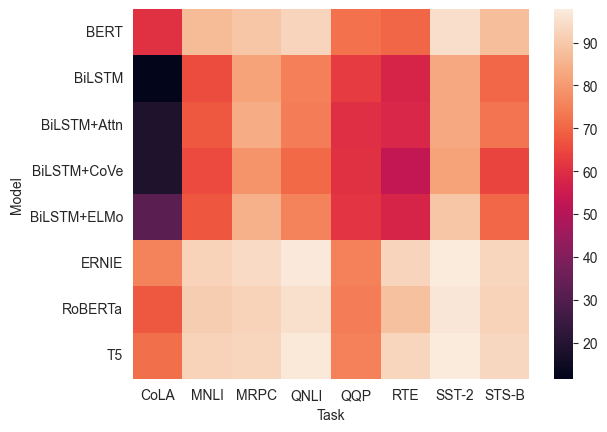

In [13]:
# Draw the heatmap
sns.heatmap(glue)

##### 2. Use `annot` to represent the cell values with text:

<Axes: xlabel='Task', ylabel='Model'>

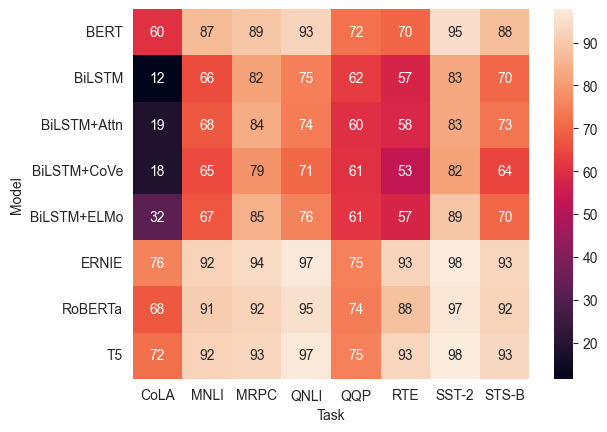

In [14]:
sns.heatmap(glue, annot=True)

##### 3. Control the annotations with a formatting string:

<Axes: xlabel='Task', ylabel='Model'>

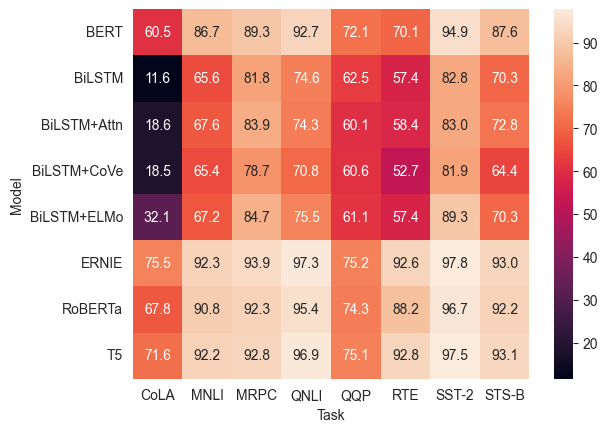

In [15]:
sns.heatmap(glue, annot=True, fmt=".1f")

##### 4. Use a separate dataframe for the annotations:

<Axes: xlabel='Task', ylabel='Model'>

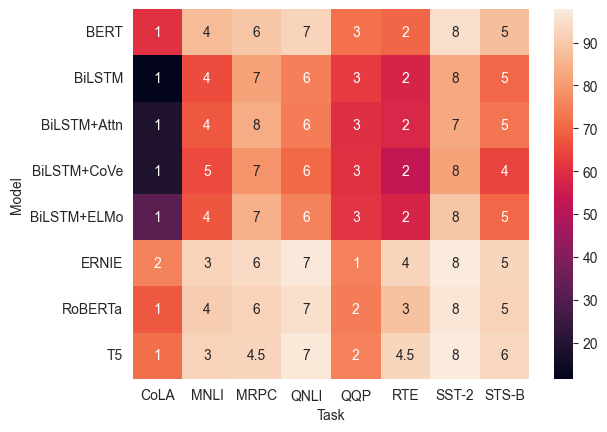

In [16]:
sns.heatmap(glue, annot=glue.rank(axis="columns"))

##### 5. Add lines between cells:

<Axes: xlabel='Task', ylabel='Model'>

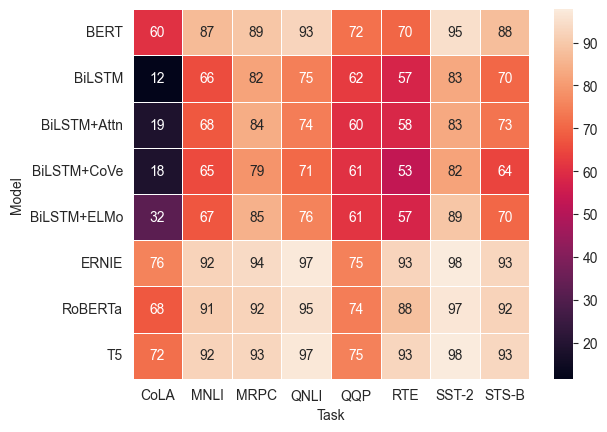

In [17]:
sns.heatmap(glue, annot=True, linewidths=0.5)

##### 6. Select a different colormap by name:

<Axes: xlabel='Task', ylabel='Model'>

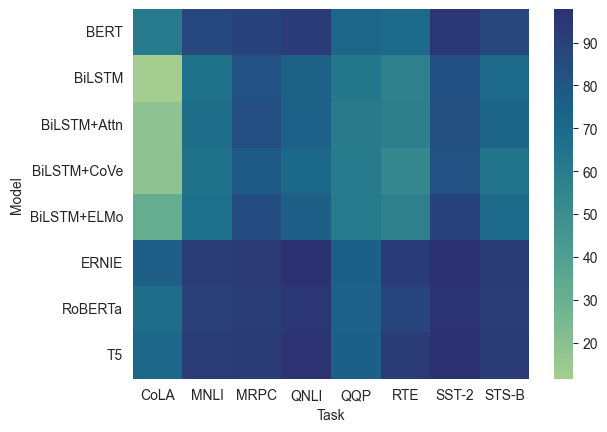

In [18]:
sns.heatmap(glue, cmap="crest")

##### 7. Or pass a colormap object:

<Axes: xlabel='Task', ylabel='Model'>

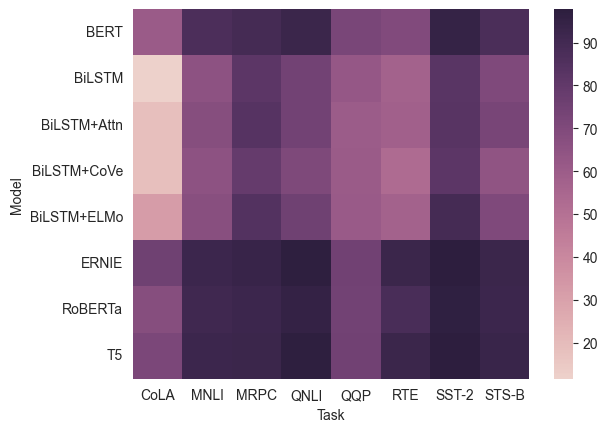

In [19]:
sns.heatmap(glue, cmap=sns.cubehelix_palette(as_cmap=True))

##### 8. Set the colormap norm (minimum and maximum points):

<Axes: xlabel='Task', ylabel='Model'>

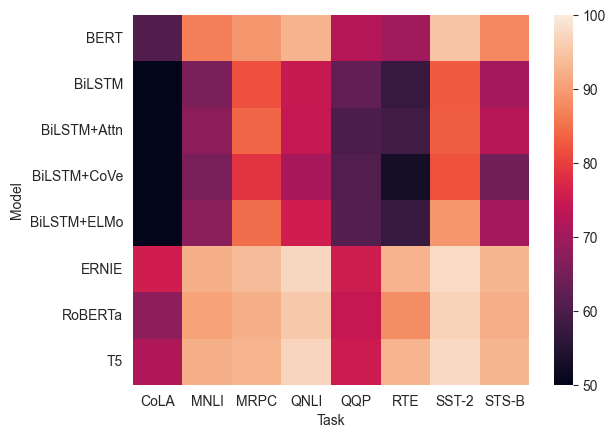

In [20]:
sns.heatmap(glue, vmin=50, vmax=100)

##### 9. Use methods on the `Axes` object to tweak the plot:

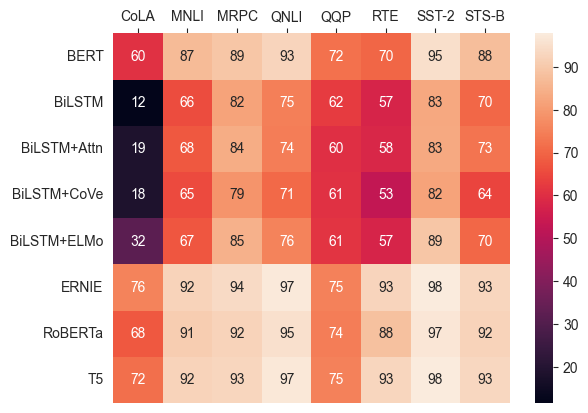

In [21]:
# Remember, heatmap returns the Axes it is plotted in
ax = sns.heatmap(glue, annot=True)
ax.set(xlabel="", ylabel="")
ax.xaxis.tick_top()